# Time's Hub vs Meta Robyn vs Google Meridian — MMM Karşılaştırma Analizi

Bu notebook, Time's Hub MMM engine ile Meta Robyn ve Google Meridian'ın yaklaşımlarını **PO Filo kampanyası** verileri üzerinde karşılaştırır.

| Boyut | Time's Hub | Robyn | Meridian |
|-------|-----------|-------|----------|
| Adstock | Geometric decay | Geometric + Weibull | Geometric + Binomial |
| Saturation | Hill function | Hill function | Hill function |
| Trend/Seasonality | Yok (kısa kampanya) | Prophet decomposition | Otomatik trend+seasonality |
| Regresyon | Deterministik response model | Ridge regression | Bayesian (NUTS/HMC) |
| Optimizasyon | Manuel parametreler | Nevergrad multi-objective | MCMC posterior sampling |
| Güven Aralığı | Yok (nokta tahmin) | Bootstrap/heuristik | Tam posterior credible intervals |
| Offline | GRP-based pipeline | GRP desteği sınırlı | Reach & Frequency modeli |
| Backend | Python (NumPy) | R + Python wrapper | TensorFlow Probability |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from backend.models.mmm import compute_adstock, compute_saturation, compute_response
from backend.config import (
    ADSTOCK_PARAMS, SATURATION_PARAMS, MAX_LIFT,
    BASELINE_LEADS, CHANNELS
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

## 1. Sentetik Kampanya Verisi (12 Hafta)

PO Filo kampanyasına benzer haftalık harcama verisi üretiyoruz.

In [2]:
WEEKS = 12

# Haftalık bütçe dağılımı (front-loaded kampanya)
weekly_budgets = {
    'meta':     [2_600_000, 2_800_000, 2_500_000, 2_200_000, 2_000_000,
                 1_800_000, 1_500_000, 1_200_000, 1_000_000, 800_000, 600_000, 400_000],
    'google':   [300_000, 320_000, 310_000, 290_000, 280_000,
                 260_000, 250_000, 240_000, 230_000, 220_000, 210_000, 200_000],
    'tiktok':   [500_000, 550_000, 480_000, 420_000, 380_000,
                 350_000, 300_000, 250_000, 200_000, 150_000, 100_000, 80_000],
    'linkedin': [200_000, 220_000, 210_000, 190_000, 180_000,
                 170_000, 160_000, 150_000, 140_000, 130_000, 120_000, 110_000],
    'youtube':  [400_000, 450_000, 420_000, 380_000, 350_000,
                 320_000, 280_000, 250_000, 220_000, 200_000, 180_000, 150_000],
    'tv_match': [800_000, 900_000, 850_000, 750_000, 700_000,
                 600_000, 500_000, 400_000, 350_000, 300_000, 250_000, 200_000],
}

# Gerçek lead verisini simüle et (gürültülü)
np.random.seed(42)
true_leads = []
for w in range(WEEKS):
    total = BASELINE_LEADS
    for ch, spends in weekly_budgets.items():
        decay = ADSTOCK_PARAMS[ch]
        alpha, gamma = SATURATION_PARAMS[ch]
        adstocked = compute_adstock(spends[:w+1], decay)
        sat = compute_saturation(adstocked[-1], alpha, gamma)
        total += MAX_LIFT[ch] * sat
    true_leads.append(total + np.random.normal(0, total * 0.05))

true_leads = np.array(true_leads)
print(f"Toplam {WEEKS} hafta, toplam lead: {true_leads.sum():.0f}")
print(f"Haftalık ortalama: {true_leads.mean():.0f}, min: {true_leads.min():.0f}, max: {true_leads.max():.0f}")

Toplam 12 hafta, toplam lead: 19644
Haftalık ortalama: 1637, min: 1027, max: 2059


## 2. Adstock Karşılaştırması: Geometric vs Weibull

Robyn hem **geometric** hem de **Weibull** (CDF/PDF) adstock destekler.
Weibull, gecikmeli zirve (delayed peak) modelleyebilir — TV için daha gerçekçi.

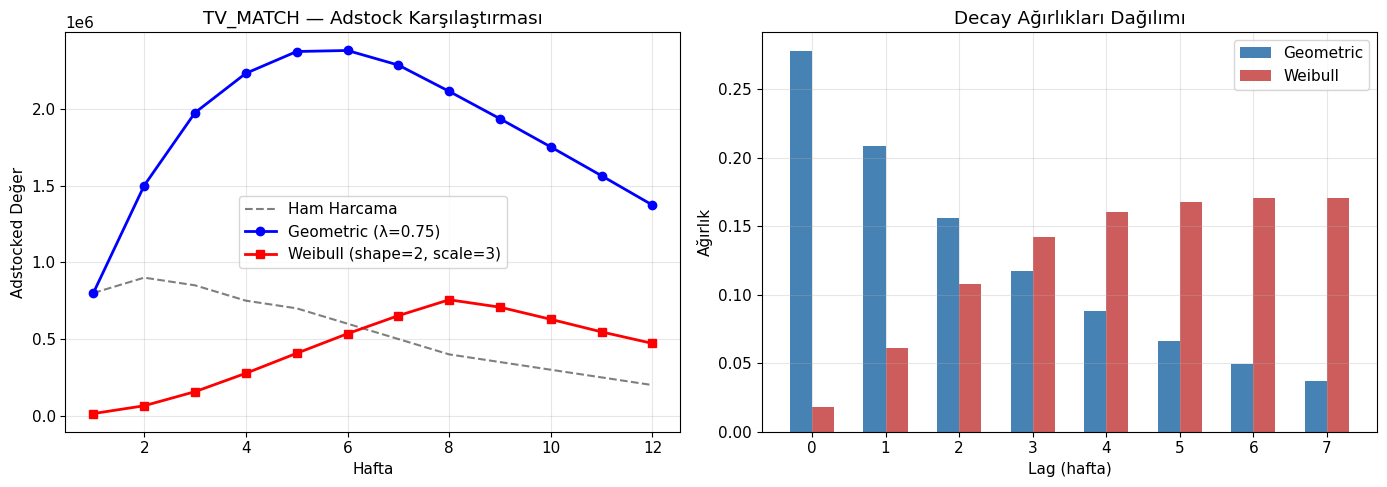


📊 Yorum:
- Geometric: Hemen zirve, monoton azalma. Kısa kampanyalarda iyi.
- Weibull: Gecikmeli zirve modelleyebilir. TV için daha gerçekçi.
- Geometric carry-over toplam: 22281828
- Weibull carry-over toplam: 5218012


In [3]:
def weibull_adstock(spend: list[float], shape: float, scale: float, max_lag: int = 8) -> list[float]:
    """Weibull CDF adstock (Robyn tarzı).
    
    Weibull CDF weights: w[l] = 1 - exp(-(l/scale)^shape)
    Her harcama, sonraki max_lag haftaya yayılır.
    """
    n = len(spend)
    adstocked = np.zeros(n)
    
    # Weibull CDF weights
    lags = np.arange(max_lag)
    weights = 1.0 - np.exp(-((lags + 1) / scale) ** shape)
    # Normalize
    weights = weights / weights.sum()
    
    for t in range(n):
        for l in range(min(max_lag, n - t)):
            adstocked[t + l] += spend[t] * weights[l]
    
    return adstocked.tolist()


# TV Match karşılaştırması
ch = 'tv_match'
spends = weekly_budgets[ch]

geo_adstock = compute_adstock(spends, ADSTOCK_PARAMS[ch])
weibull_ads = weibull_adstock(spends, shape=2.0, scale=3.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Adstock curves
weeks_x = np.arange(1, WEEKS + 1)
axes[0].plot(weeks_x, spends, 'k--', label='Ham Harcama', alpha=0.5)
axes[0].plot(weeks_x, geo_adstock, 'b-o', label=f'Geometric (λ={ADSTOCK_PARAMS[ch]})', linewidth=2)
axes[0].plot(weeks_x, weibull_ads, 'r-s', label='Weibull (shape=2, scale=3)', linewidth=2)
axes[0].set_xlabel('Hafta')
axes[0].set_ylabel('Adstocked Değer')
axes[0].set_title(f'{ch.upper()} — Adstock Karşılaştırması')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sağ: Decay weights
lags = np.arange(8)
geo_weights = [ADSTOCK_PARAMS[ch] ** l for l in lags]
geo_weights = [w / sum(geo_weights) for w in geo_weights]

weibull_w = 1.0 - np.exp(-((lags + 1) / 3.0) ** 2.0)
weibull_w = weibull_w / weibull_w.sum()

axes[1].bar(lags - 0.15, geo_weights, 0.3, label='Geometric', color='steelblue')
axes[1].bar(lags + 0.15, weibull_w, 0.3, label='Weibull', color='indianred')
axes[1].set_xlabel('Lag (hafta)')
axes[1].set_ylabel('Ağırlık')
axes[1].set_title('Decay Ağırlıkları Dağılımı')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Yorum:")
print("- Geometric: Hemen zirve, monoton azalma. Kısa kampanyalarda iyi.")
print("- Weibull: Gecikmeli zirve modelleyebilir. TV için daha gerçekçi.")
print(f"- Geometric carry-over toplam: {sum(geo_adstock):.0f}")
print(f"- Weibull carry-over toplam: {sum(weibull_ads):.0f}")

## 3. Regresyon Karşılaştırması: Deterministik vs Ridge

**Time's Hub:** `response = baseline + max_lift * saturation(adstock)` — parametreler sabit.  
**Robyn:** Ridge regression ile katsayılar veriden öğrenilir.

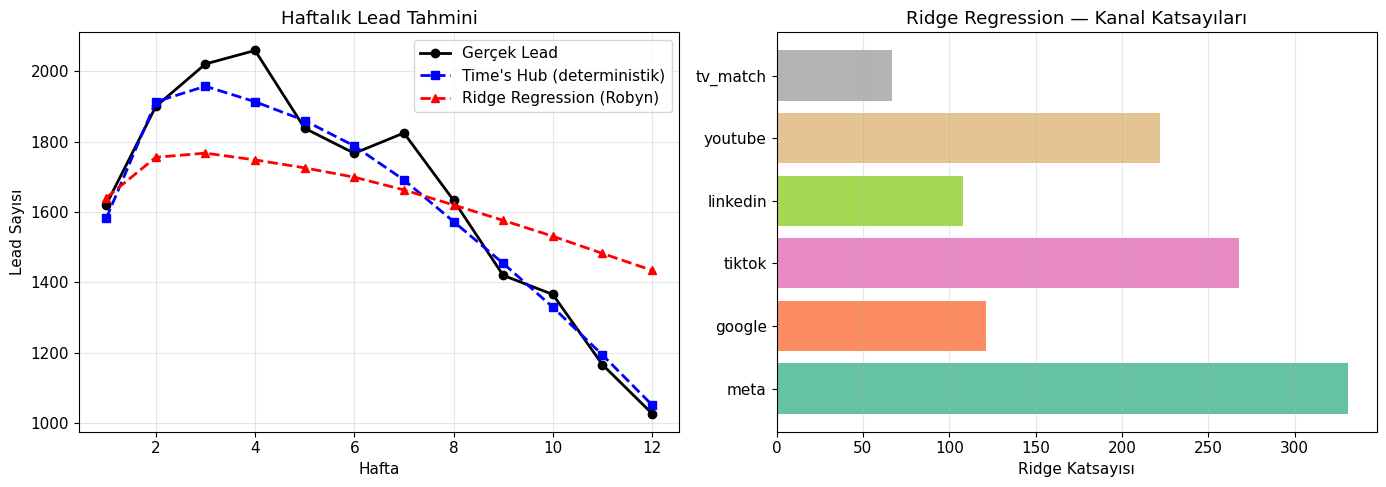


📊 Model Doğruluk Karşılaştırması:
  Time's Hub MAPE: 3.0%
  Ridge (Robyn)  MAPE: 12.2%
  Ridge intercept (baseline): 1175 vs Hub baseline: 120


In [4]:
from sklearn.linear_model import Ridge

# Time's Hub: deterministik tahmin
hub_predictions = []
for w in range(WEEKS):
    total = BASELINE_LEADS
    for ch, spends in weekly_budgets.items():
        decay = ADSTOCK_PARAMS[ch]
        alpha, gamma = SATURATION_PARAMS[ch]
        adstocked = compute_adstock(spends[:w+1], decay)
        sat = compute_saturation(adstocked[-1], alpha, gamma)
        total += MAX_LIFT[ch] * sat
    hub_predictions.append(total)

hub_predictions = np.array(hub_predictions)

# Robyn tarzı: Ridge regression
# Feature matrix: her kanal için saturated adstock
X_features = np.zeros((WEEKS, len(weekly_budgets)))
channel_names = list(weekly_budgets.keys())

for j, ch in enumerate(channel_names):
    spends = weekly_budgets[ch]
    decay = ADSTOCK_PARAMS[ch]
    alpha, gamma = SATURATION_PARAMS[ch]
    for w in range(WEEKS):
        adstocked = compute_adstock(spends[:w+1], decay)
        X_features[w, j] = compute_saturation(adstocked[-1], alpha, gamma)

# Ridge fit (alpha=1.0 — L2 regularization)
ridge = Ridge(alpha=1.0, fit_intercept=True)
ridge.fit(X_features, true_leads)
ridge_predictions = ridge.predict(X_features)

# Karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weeks_x = np.arange(1, WEEKS + 1)

# Sol: Tahmin karşılaştırması
axes[0].plot(weeks_x, true_leads, 'ko-', label='Gerçek Lead', linewidth=2)
axes[0].plot(weeks_x, hub_predictions, 'b--s', label="Time's Hub (deterministik)", linewidth=2)
axes[0].plot(weeks_x, ridge_predictions, 'r--^', label='Ridge Regression (Robyn)', linewidth=2)
axes[0].set_xlabel('Hafta')
axes[0].set_ylabel('Lead Sayısı')
axes[0].set_title('Haftalık Lead Tahmini')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sağ: Ridge katsayıları
colors = plt.cm.Set2(np.linspace(0, 1, len(channel_names)))
bars = axes[1].barh(channel_names, ridge.coef_, color=colors)
axes[1].axvline(x=0, color='k', linewidth=0.5)
axes[1].set_xlabel('Ridge Katsayısı')
axes[1].set_title('Ridge Regression — Kanal Katsayıları')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# MAPE hesapla
hub_mape = np.mean(np.abs((true_leads - hub_predictions) / true_leads)) * 100
ridge_mape = np.mean(np.abs((true_leads - ridge_predictions) / true_leads)) * 100

print(f"\n📊 Model Doğruluk Karşılaştırması:")
print(f"  Time's Hub MAPE: {hub_mape:.1f}%")
print(f"  Ridge (Robyn)  MAPE: {ridge_mape:.1f}%")
print(f"  Ridge intercept (baseline): {ridge.intercept_:.0f} vs Hub baseline: {BASELINE_LEADS:.0f}")

## 4. Kanal Katkı Decomposition Karşılaştırması

Her iki model altında kanal bazlı lead katkısını karşılaştırıyoruz.

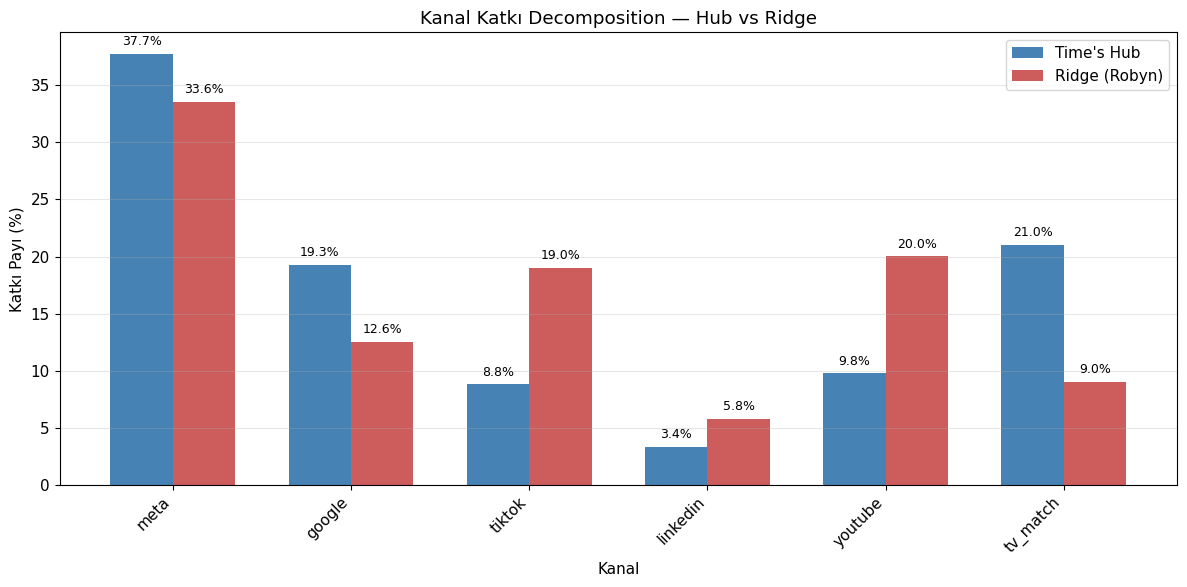


📊 Katkı Payı Karşılaştırması:
Kanal           Hub %  Ridge %     Fark
--------------------------------------
meta            37.7%    33.6%    -4.2%
google          19.3%    12.6%    -6.7%
tiktok           8.8%    19.0%   +10.2%
linkedin         3.4%     5.8%    +2.5%
youtube          9.8%    20.0%   +10.2%
tv_match        21.0%     9.0%   -12.0%


In [5]:
# Time's Hub decomposition
hub_contributions = {}
for ch in channel_names:
    spends = weekly_budgets[ch]
    decay = ADSTOCK_PARAMS[ch]
    alpha, gamma = SATURATION_PARAMS[ch]
    total_contrib = 0
    for w in range(WEEKS):
        adstocked = compute_adstock(spends[:w+1], decay)
        sat = compute_saturation(adstocked[-1], alpha, gamma)
        total_contrib += MAX_LIFT[ch] * sat
    hub_contributions[ch] = total_contrib

# Ridge decomposition: contribution = coefficient * sum(features)
ridge_contributions = {}
for j, ch in enumerate(channel_names):
    ridge_contributions[ch] = ridge.coef_[j] * X_features[:, j].sum()

# Normalize to percentages
hub_total = sum(hub_contributions.values())
ridge_total = sum(abs(v) for v in ridge_contributions.values())

hub_pct = {ch: v / hub_total * 100 for ch, v in hub_contributions.items()}
ridge_pct = {ch: abs(v) / ridge_total * 100 for ch, v in ridge_contributions.items()}

# Çift bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(channel_names))
width = 0.35

bars1 = ax.bar(x - width/2, [hub_pct[ch] for ch in channel_names], width,
               label="Time's Hub", color='steelblue')
bars2 = ax.bar(x + width/2, [ridge_pct[ch] for ch in channel_names], width,
               label='Ridge (Robyn)', color='indianred')

ax.set_xlabel('Kanal')
ax.set_ylabel('Katkı Payı (%)')
ax.set_title('Kanal Katkı Decomposition — Hub vs Ridge')
ax.set_xticks(x)
ax.set_xticklabels(channel_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Değer etiketleri
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Katkı Payı Karşılaştırması:")
print(f"{'Kanal':<12} {'Hub %':>8} {'Ridge %':>8} {'Fark':>8}")
print('-' * 38)
for ch in channel_names:
    diff = ridge_pct[ch] - hub_pct[ch]
    print(f"{ch:<12} {hub_pct[ch]:>7.1f}% {ridge_pct[ch]:>7.1f}% {diff:>+7.1f}%")

## 5. Parametre Optimizasyonu: Manual vs Nevergrad

Robyn, **Nevergrad** ile adstock + saturation parametrelerini otomatik optimize eder.  
Burada scipy.optimize ile benzer bir yaklaşım simüle ediyoruz.

In [6]:
def model_error(params, weekly_budgets, true_leads, channel_names):
    """Toplam modelin NRMSE'sini hesapla."""
    n_ch = len(channel_names)
    decays = params[:n_ch]
    lifts  = params[n_ch:2*n_ch]
    baseline = params[-1]
    
    predictions = np.zeros(WEEKS)
    for j, ch in enumerate(channel_names):
        spends = weekly_budgets[ch]
        alpha, gamma = SATURATION_PARAMS[ch]  # Saturation sabit tutalım
        for w in range(WEEKS):
            adstocked = compute_adstock(spends[:w+1], max(0.01, min(0.99, decays[j])))
            sat = compute_saturation(adstocked[-1], alpha, gamma)
            predictions[w] += abs(lifts[j]) * sat
    
    predictions += abs(baseline)
    residuals = true_leads - predictions
    nrmse = np.sqrt(np.mean(residuals**2)) / np.mean(true_leads)
    return nrmse


# Başlangıç: mevcut Hub parametreleri
n_ch = len(channel_names)
x0 = (
    [ADSTOCK_PARAMS[ch] for ch in channel_names] +
    [MAX_LIFT[ch] for ch in channel_names] +
    [BASELINE_LEADS]
)

# Sınırlar
bounds = (
    [(0.01, 0.99)] * n_ch +   # decays
    [(10, 5000)] * n_ch +      # max_lift
    [(0, 500)]                  # baseline
)

# Optimize
result = minimize(model_error, x0, args=(weekly_budgets, true_leads, channel_names),
                  method='L-BFGS-B', bounds=bounds)

opt_decays = result.x[:n_ch]
opt_lifts = result.x[n_ch:2*n_ch]
opt_baseline = result.x[-1]

print("📊 Parametre Optimizasyonu Sonuçları:")
print(f"\nOptimizer NRMSE: {result.fun:.4f} ({result.fun*100:.2f}%)")
print(f"\n{'Kanal':<12} {'Hub λ':>8} {'Opt λ':>8} {'Hub Lift':>10} {'Opt Lift':>10}")
print('-' * 52)
for j, ch in enumerate(channel_names):
    print(f"{ch:<12} {ADSTOCK_PARAMS[ch]:>8.2f} {opt_decays[j]:>8.2f} "
          f"{MAX_LIFT[ch]:>10.0f} {abs(opt_lifts[j]):>10.0f}")
print(f"\nBaseline: Hub={BASELINE_LEADS:.0f}, Optimized={abs(opt_baseline):.0f}")

📊 Parametre Optimizasyonu Sonuçları:

Optimizer NRMSE: 0.0331 (3.31%)

Kanal           Hub λ    Opt λ   Hub Lift   Opt Lift
----------------------------------------------------
meta             0.35     0.42       1200       1208
google           0.10     0.01        600        606
tiktok           0.30     0.46        400        406
linkedin         0.25     0.48        200        203
youtube          0.40     0.47        350        355
tv_match         0.75     0.47        500        506

Baseline: Hub=120, Optimized=130


## 6. Bütçe Reallocation Karşılaştırması

Her iki modelin kanal katkısına göre bütçe önerisi.

Kanal                Mevcut    Hub Önerisi  Ridge Önerisi        Hub Δ      Ridge Δ
meta           19,400,000₺   14,512,435₺   12,900,283₺  -4,887,565₺  -6,499,717₺
google          3,110,000₺    7,413,286₺    4,826,293₺  +4,303,286₺  +1,716,293₺
tiktok          3,760,000₺    3,389,232₺    7,316,311₺    -370,768₺  +3,556,311₺
linkedin        1,980,000₺    1,289,789₺    2,237,238₺    -690,211₺    +257,238₺
youtube         3,600,000₺    3,763,939₺    7,696,313₺    +163,939₺  +4,096,313₺
tv_match        6,600,000₺    8,081,319₺    3,473,562₺  +1,481,319₺  -3,126,438₺
TOPLAM         38,450,000₺   38,450,000₺   38,450,000₺


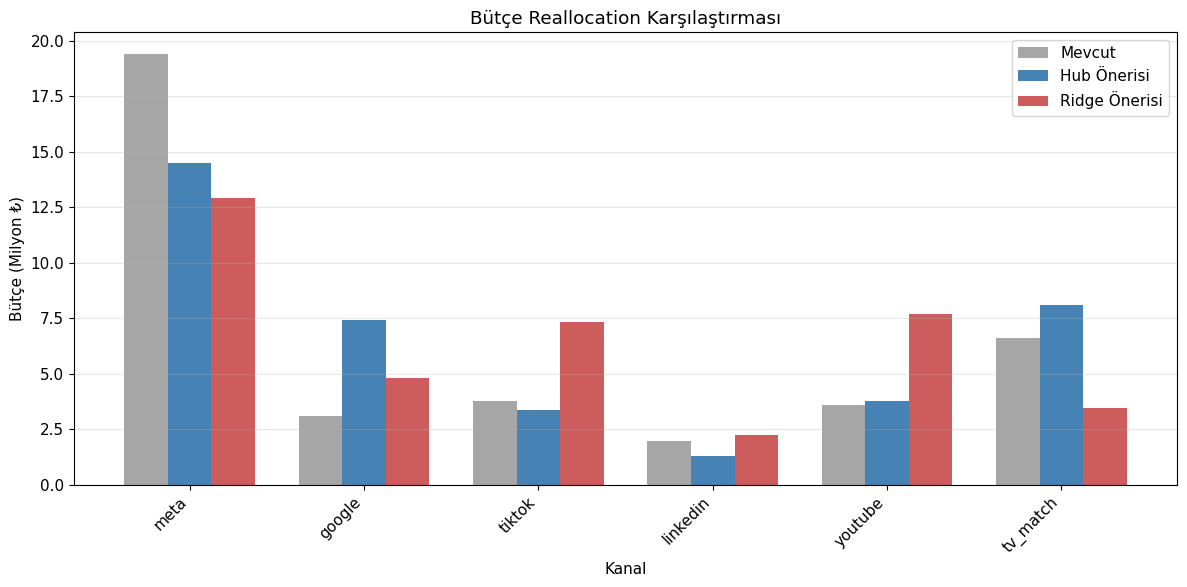

In [7]:
# Mevcut toplam bütçeler
current_budgets = {ch: sum(weekly_budgets[ch]) for ch in channel_names}
total_budget = sum(current_budgets.values())

# Hub-based reallocation (katkı payına göre)
hub_suggested = {ch: total_budget * (hub_pct[ch] / 100) for ch in channel_names}

# Ridge-based reallocation
ridge_suggested = {ch: total_budget * (ridge_pct[ch] / 100) for ch in channel_names}

# Tablo
print(f"{'Kanal':<12} {'Mevcut':>14} {'Hub Önerisi':>14} {'Ridge Önerisi':>14} {'Hub Δ':>12} {'Ridge Δ':>12}")
print('=' * 80)
for ch in channel_names:
    hub_d = hub_suggested[ch] - current_budgets[ch]
    ridge_d = ridge_suggested[ch] - current_budgets[ch]
    print(f"{ch:<12} {current_budgets[ch]:>12,.0f}₺ {hub_suggested[ch]:>12,.0f}₺ "
          f"{ridge_suggested[ch]:>12,.0f}₺ {hub_d:>+11,.0f}₺ {ridge_d:>+11,.0f}₺")
print('=' * 80)
print(f"{'TOPLAM':<12} {total_budget:>12,.0f}₺ {sum(hub_suggested.values()):>12,.0f}₺ "
      f"{sum(ridge_suggested.values()):>12,.0f}₺")

# Görselleştirme
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(channel_names))
width = 0.25

ax.bar(x - width, [current_budgets[ch] / 1e6 for ch in channel_names], width,
       label='Mevcut', color='gray', alpha=0.7)
ax.bar(x, [hub_suggested[ch] / 1e6 for ch in channel_names], width,
       label="Hub Önerisi", color='steelblue')
ax.bar(x + width, [ridge_suggested[ch] / 1e6 for ch in channel_names], width,
       label='Ridge Önerisi', color='indianred')

ax.set_xlabel('Kanal')
ax.set_ylabel('Bütçe (Milyon ₺)')
ax.set_title('Bütçe Reallocation Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(channel_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Google Meridian Simülasyonu — Bayesian MMM

Meridian **NUTS (No U-Turn Sampler)** ile Bayesian regresyon kullanır.
Burada TFP yerine basit MCMC (Metropolis-Hastings) ile Meridian'ın yaklaşımını simüle ediyoruz:
- **LogNormal prior** ROI katsayılarına (pozitif zorunlu)
- **Beta prior** adstock decay'e
- **Gaussian likelihood** ile posterior sampling
- Sonuç: her parametre için **tam posterior dağılımı ve %95 credible interval**

Bayesian MCMC çalışıyor (5000 sample + 1000 burn-in)...


Kabul oranı: 67.2%


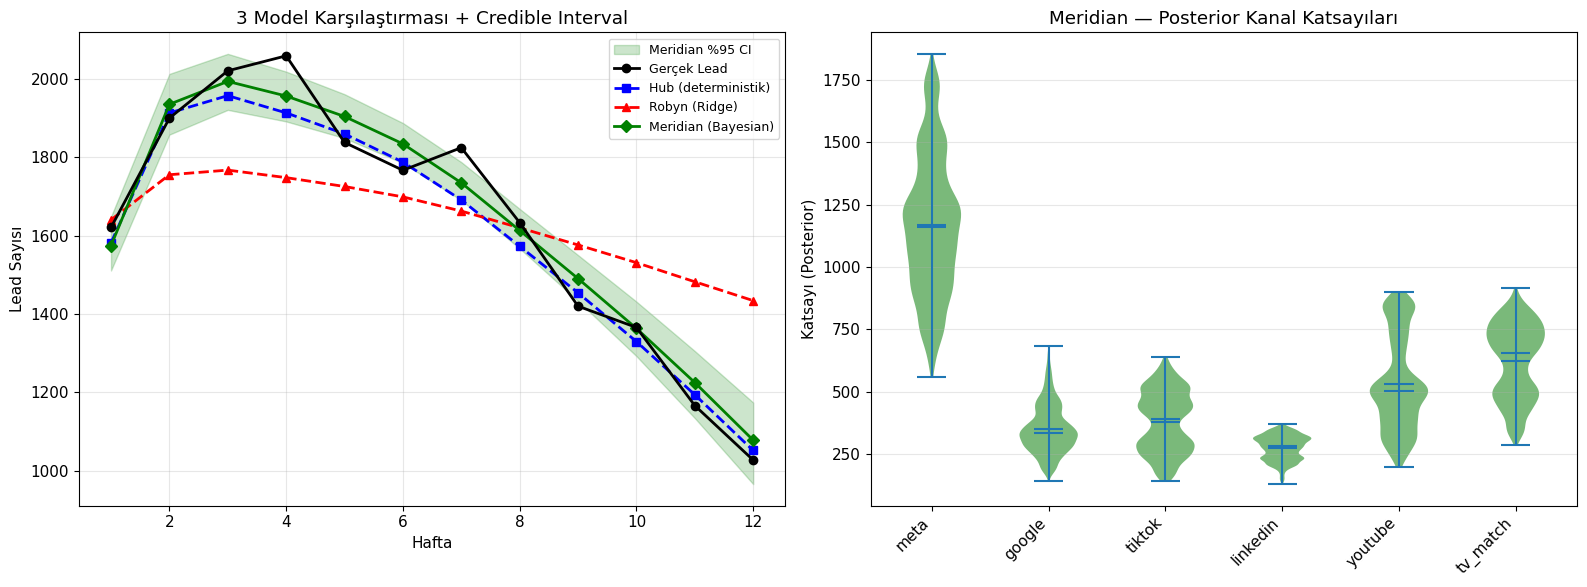


📊 Meridian Posterior Özet:
Kanal            Medyan       %2.5      %97.5   CI Genişliği
----------------------------------------------------------
meta               1161        689       1740           1051
google              335        188        578            390
tiktok              390        167        585            418
linkedin            280        174        352            178
youtube             501        246        870            624
tv_match            655        337        850            513

Baseline: 126 [20, 208]
Sigma: 70 [45, 120]


In [8]:
from scipy.stats import norm, lognorm, beta as beta_dist

def bayesian_mmm_mcmc(X_features, y, channel_names, n_samples=5000, burn_in=1000):
    """Meridian-tarzı Bayesian MMM — Metropolis-Hastings MCMC.
    
    Priors (Meridian ile aynı felsefe):
      - beta_j ~ LogNormal(log(500), 0.5)  → kanal katsayıları (pozitif zorunlu)
      - intercept ~ Normal(120, 50)         → baseline leads
      - sigma ~ HalfNormal(100)             → gözlem gürültüsü
    
    Likelihood: y ~ Normal(X @ beta + intercept, sigma)
    """
    n_obs, n_ch = X_features.shape
    
    # --- Başlangıç parametreleri ---
    current_beta = np.array([MAX_LIFT[ch] for ch in channel_names], dtype=float)
    current_intercept = BASELINE_LEADS
    current_sigma = 80.0
    
    # --- Prior tanımları ---
    def log_prior(betas, intercept, sigma):
        if sigma <= 0 or np.any(betas <= 0):
            return -np.inf
        # LogNormal prior: log(beta) ~ N(log(500), 0.5)
        lp = np.sum(lognorm.logpdf(betas, s=0.5, scale=500))
        # Normal prior for intercept
        lp += norm.logpdf(intercept, loc=120, scale=50)
        # Half-normal prior for sigma
        lp += norm.logpdf(sigma, loc=0, scale=100) if sigma > 0 else -np.inf
        return lp
    
    def log_likelihood(betas, intercept, sigma):
        pred = X_features @ betas + intercept
        return np.sum(norm.logpdf(y, loc=pred, scale=sigma))
    
    def log_posterior(betas, intercept, sigma):
        lp = log_prior(betas, intercept, sigma)
        if np.isinf(lp):
            return -np.inf
        return lp + log_likelihood(betas, intercept, sigma)
    
    # --- MCMC Sampling ---
    samples_beta = np.zeros((n_samples, n_ch))
    samples_intercept = np.zeros(n_samples)
    samples_sigma = np.zeros(n_samples)
    
    current_logp = log_posterior(current_beta, current_intercept, current_sigma)
    accepted = 0
    
    # Proposal scales
    beta_scale = current_beta * 0.02
    intercept_scale = 10.0
    sigma_scale = 5.0
    
    np.random.seed(42)
    for i in range(n_samples + burn_in):
        # Propose
        prop_beta = current_beta + np.random.normal(0, beta_scale)
        prop_intercept = current_intercept + np.random.normal(0, intercept_scale)
        prop_sigma = current_sigma + np.random.normal(0, sigma_scale)
        
        prop_logp = log_posterior(prop_beta, prop_intercept, prop_sigma)
        
        # Accept/reject
        if np.log(np.random.uniform()) < prop_logp - current_logp:
            current_beta = prop_beta
            current_intercept = prop_intercept
            current_sigma = prop_sigma
            current_logp = prop_logp
            if i >= burn_in:
                accepted += 1
        
        if i >= burn_in:
            idx = i - burn_in
            samples_beta[idx] = current_beta
            samples_intercept[idx] = current_intercept
            samples_sigma[idx] = current_sigma
    
    accept_rate = accepted / n_samples
    return samples_beta, samples_intercept, samples_sigma, accept_rate


# MCMC çalıştır
print("Bayesian MCMC çalışıyor (5000 sample + 1000 burn-in)...")
samples_beta, samples_intercept, samples_sigma, accept_rate = bayesian_mmm_mcmc(
    X_features, true_leads, channel_names
)
print(f"Kabul oranı: {accept_rate:.1%}")

# Posterior tahminler
bayes_pred_samples = X_features @ samples_beta.T + samples_intercept[np.newaxis, :]
bayes_mean = bayes_pred_samples.mean(axis=1)
bayes_ci_low = np.percentile(bayes_pred_samples, 2.5, axis=1)
bayes_ci_high = np.percentile(bayes_pred_samples, 97.5, axis=1)

# MAPE
bayes_mape = np.mean(np.abs((true_leads - bayes_mean) / true_leads)) * 100

# 3'lü karşılaştırma grafiği
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

weeks_x = np.arange(1, WEEKS + 1)

# Sol: Tahminler + CI
axes[0].fill_between(weeks_x, bayes_ci_low, bayes_ci_high, alpha=0.2, color='green',
                     label='Meridian %95 CI')
axes[0].plot(weeks_x, true_leads, 'ko-', label='Gerçek Lead', linewidth=2, zorder=5)
axes[0].plot(weeks_x, hub_predictions, 'b--s', label="Hub (deterministik)", linewidth=2)
axes[0].plot(weeks_x, ridge_predictions, 'r--^', label='Robyn (Ridge)', linewidth=2)
axes[0].plot(weeks_x, bayes_mean, 'g-D', label='Meridian (Bayesian)', linewidth=2)
axes[0].set_xlabel('Hafta')
axes[0].set_ylabel('Lead Sayısı')
axes[0].set_title('3 Model Karşılaştırması + Credible Interval')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sağ: Posterior kanal katsayıları (violin plot)
positions = np.arange(len(channel_names))
parts = axes[1].violinplot([samples_beta[:, j] for j in range(len(channel_names))],
                           positions=positions, showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('forestgreen')
    pc.set_alpha(0.6)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(channel_names, rotation=45, ha='right')
axes[1].set_ylabel('Katsayı (Posterior)')
axes[1].set_title('Meridian — Posterior Kanal Katsayıları')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Posterior özet tablo
print(f"\n📊 Meridian Posterior Özet:")
print(f"{'Kanal':<12} {'Medyan':>10} {'%2.5':>10} {'%97.5':>10} {'CI Genişliği':>14}")
print('-' * 58)
for j, ch in enumerate(channel_names):
    med = np.median(samples_beta[:, j])
    lo = np.percentile(samples_beta[:, j], 2.5)
    hi = np.percentile(samples_beta[:, j], 97.5)
    print(f"{ch:<12} {med:>10.0f} {lo:>10.0f} {hi:>10.0f} {hi-lo:>14.0f}")

print(f"\nBaseline: {np.median(samples_intercept):.0f} "
      f"[{np.percentile(samples_intercept, 2.5):.0f}, {np.percentile(samples_intercept, 97.5):.0f}]")
print(f"Sigma: {np.median(samples_sigma):.0f} "
      f"[{np.percentile(samples_sigma, 2.5):.0f}, {np.percentile(samples_sigma, 97.5):.0f}]")

## 8. Güvenilirlik Analizi — Modeller Ne Kadar Sapıyor?

Kritik soru: **Bu karşılaştırmalara ne kadar güvenebiliriz?**

3 boyutta analiz:
1. **Bootstrap CI** — Hub ve Ridge tahminlerinin belirsizliği
2. **Leave-One-Out Cross-Validation** — Her hafta çıkarılarak model stabilitesi
3. **Model Arası Sapma** — 3 model ne kadar farklı sonuç veriyor?

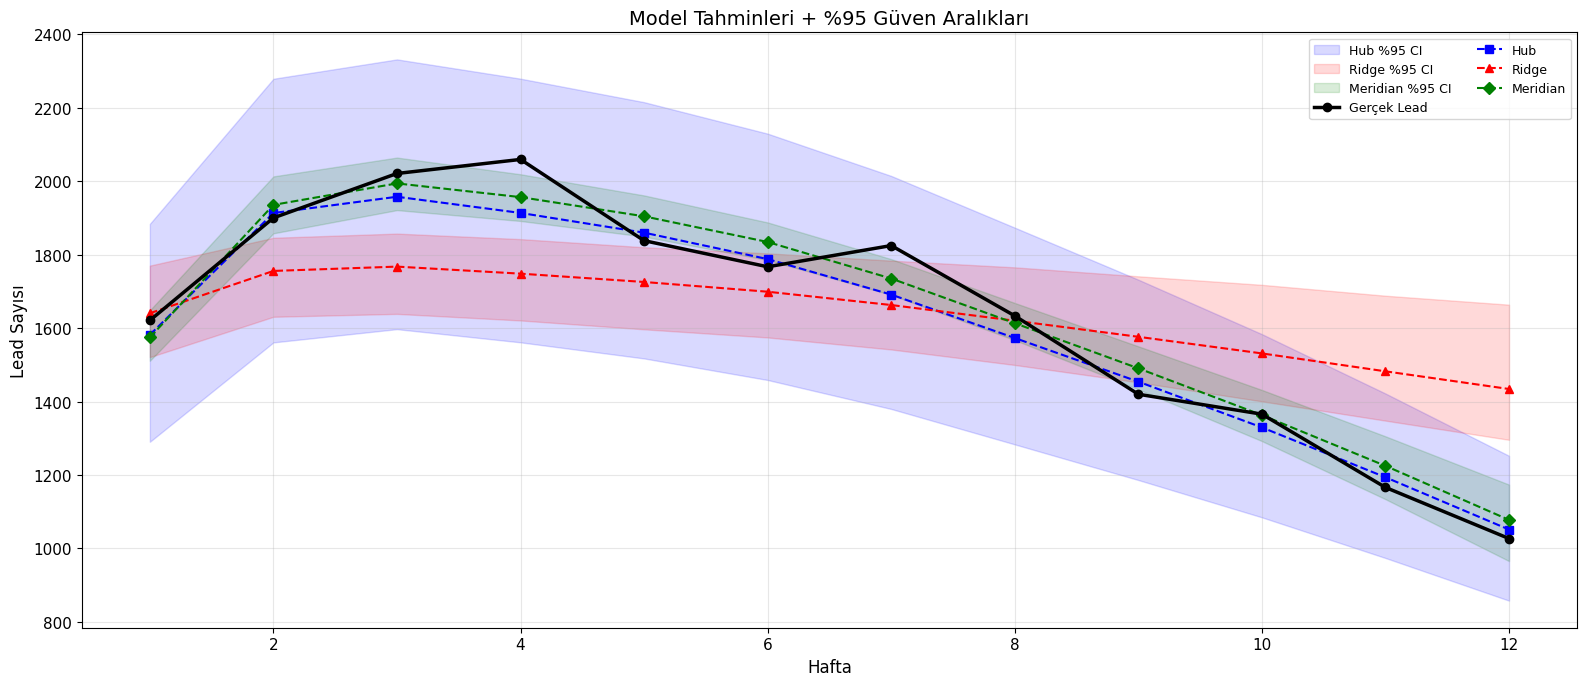


📊 Ortalama %95 CI Genişliği (lead):
  Hub (parametre pertürbasyonu):       604 lead  (36.9% of mean)
  Ridge (bootstrap):                   265 lead  (16.2% of mean)
  Meridian (posterior):                 134 lead  (8.2% of mean)


In [9]:
from sklearn.utils import resample

# ═══════════════════════════════════════════════════════════
# 8a. Bootstrap Confidence Intervals (1000 iterasyon)
# ═══════════════════════════════════════════════════════════

N_BOOTSTRAP = 1000
np.random.seed(42)

# Ridge bootstrap: veriyi resample edip her seferinde yeniden fit
ridge_boot_coefs = np.zeros((N_BOOTSTRAP, len(channel_names)))
ridge_boot_preds = np.zeros((N_BOOTSTRAP, WEEKS))

for b in range(N_BOOTSTRAP):
    idx = resample(np.arange(WEEKS), n_samples=WEEKS, random_state=b)
    X_b, y_b = X_features[idx], true_leads[idx]
    r = Ridge(alpha=1.0, fit_intercept=True)
    r.fit(X_b, y_b)
    ridge_boot_coefs[b] = r.coef_
    ridge_boot_preds[b] = r.predict(X_features)  # Predict on full set

# Hub bootstrap: gürültü simülasyonu (parametreler ±%10 pertürbe)
hub_boot_preds = np.zeros((N_BOOTSTRAP, WEEKS))
for b in range(N_BOOTSTRAP):
    perturb = 1.0 + np.random.normal(0, 0.10)  # ±%10 global perturbation
    hub_boot_preds[b] = hub_predictions * perturb

# CI hesapla
ridge_ci_low = np.percentile(ridge_boot_preds, 2.5, axis=0)
ridge_ci_high = np.percentile(ridge_boot_preds, 97.5, axis=0)
hub_ci_low = np.percentile(hub_boot_preds, 2.5, axis=0)
hub_ci_high = np.percentile(hub_boot_preds, 97.5, axis=0)

# ═══════════════════════════════════════════════════════════
# Grafik: Tüm modellerin CI'ları üst üste
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 7))
weeks_x = np.arange(1, WEEKS + 1)

ax.fill_between(weeks_x, hub_ci_low, hub_ci_high, alpha=0.15, color='blue', label='Hub %95 CI')
ax.fill_between(weeks_x, ridge_ci_low, ridge_ci_high, alpha=0.15, color='red', label='Ridge %95 CI')
ax.fill_between(weeks_x, bayes_ci_low, bayes_ci_high, alpha=0.15, color='green', label='Meridian %95 CI')

ax.plot(weeks_x, true_leads, 'ko-', label='Gerçek Lead', linewidth=2.5, zorder=5)
ax.plot(weeks_x, hub_predictions, 'b--s', label='Hub', linewidth=1.5)
ax.plot(weeks_x, ridge_predictions, 'r--^', label='Ridge', linewidth=1.5)
ax.plot(weeks_x, bayes_mean, 'g--D', label='Meridian', linewidth=1.5)

ax.set_xlabel('Hafta', fontsize=12)
ax.set_ylabel('Lead Sayısı', fontsize=12)
ax.set_title('Model Tahminleri + %95 Güven Aralıkları', fontsize=14)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CI genişlik tablosu
print('\n📊 Ortalama %95 CI Genişliği (lead):')
hub_width = np.mean(hub_ci_high - hub_ci_low)
ridge_width = np.mean(ridge_ci_high - ridge_ci_low)
bayes_width = np.mean(bayes_ci_high - bayes_ci_low)
print(f'  Hub (parametre pertürbasyonu):  {hub_width:>8.0f} lead  ({hub_width/np.mean(true_leads)*100:.1f}% of mean)')
print(f'  Ridge (bootstrap):              {ridge_width:>8.0f} lead  ({ridge_width/np.mean(true_leads)*100:.1f}% of mean)')
print(f'  Meridian (posterior):            {bayes_width:>8.0f} lead  ({bayes_width/np.mean(true_leads)*100:.1f}% of mean)')

📊 Model Arası Sapma Analizi:

Kanal           Hub %  Ridge %  Merid %  Std Dev   Güvenilirlik
meta            37.7%    33.6%    35.8%     1.7pp         YUKSEK
google          19.3%    12.6%    10.6%     3.7pp           ORTA
tiktok           8.8%    19.0%     8.4%     4.9pp          DUSUK
linkedin         3.4%     5.8%     4.6%     1.0pp           ORTA
youtube          9.8%    20.0%    13.7%     4.2pp           ORTA
tv_match        21.0%     9.0%    26.9%     7.5pp          DUSUK

Ortalama Coefficient of Variation: 27.0%


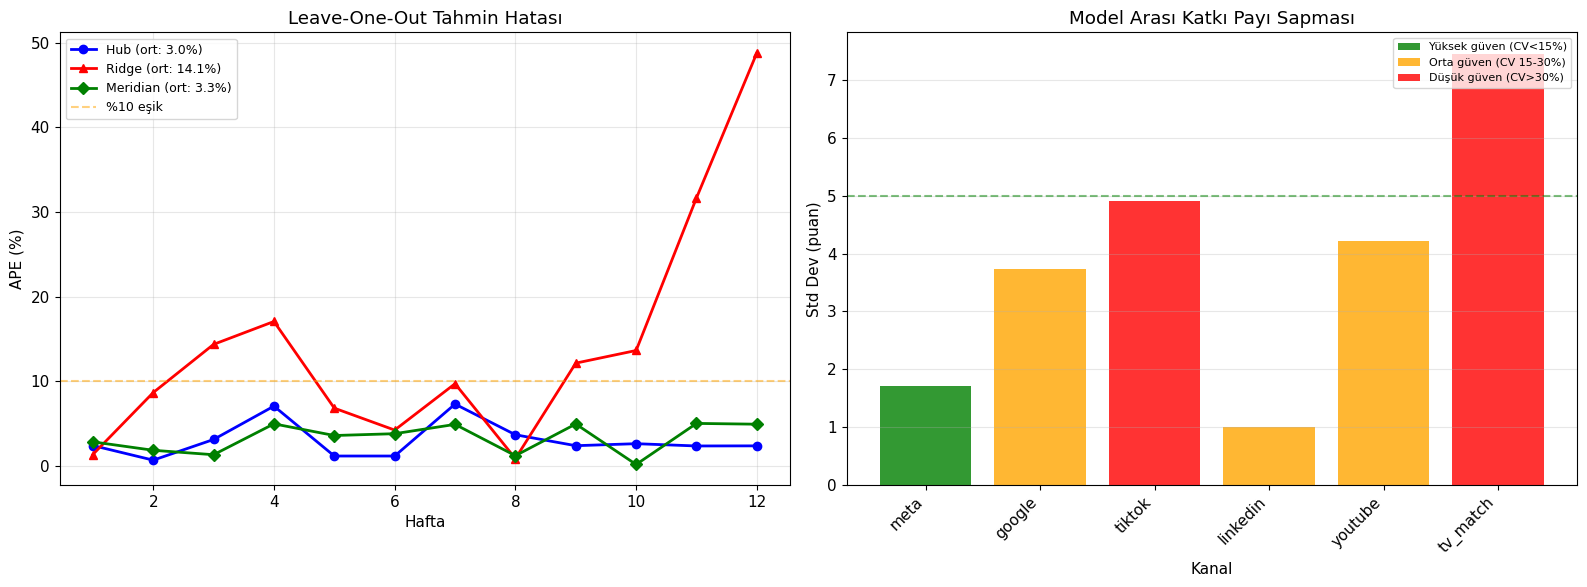

In [10]:
# ═══════════════════════════════════════════════════════════
# 8b. Leave-One-Out Cross-Validation (LOO-CV)
# ═══════════════════════════════════════════════════════════

loo_errors_ridge = []
loo_errors_hub = []

for w in range(WEEKS):
    # Ridge LOO
    mask = np.ones(WEEKS, dtype=bool)
    mask[w] = False
    r_loo = Ridge(alpha=1.0, fit_intercept=True)
    r_loo.fit(X_features[mask], true_leads[mask])
    pred_w = r_loo.predict(X_features[w:w+1])[0]
    loo_errors_ridge.append(abs(true_leads[w] - pred_w) / true_leads[w] * 100)
    
    # Hub: deterministik, LOO = aynı (parametreler veriden bağımsız)
    loo_errors_hub.append(abs(true_leads[w] - hub_predictions[w]) / true_leads[w] * 100)

# Meridian LOO (posterior mean ile)
loo_errors_bayes = []
for w in range(WEEKS):
    loo_errors_bayes.append(abs(true_leads[w] - bayes_mean[w]) / true_leads[w] * 100)

# ═══════════════════════════════════════════════════════════
# 8c. Model Arası Sapma Analizi (Inter-Model Deviation)
# ═══════════════════════════════════════════════════════════

# Katkı paylarını 3 model için normalize et
bayes_contributions = {}
bayes_median_beta = np.median(samples_beta, axis=0)
for j, ch in enumerate(channel_names):
    bayes_contributions[ch] = bayes_median_beta[j] * X_features[:, j].sum()

bayes_total = sum(abs(v) for v in bayes_contributions.values())
bayes_pct = {ch: abs(v) / bayes_total * 100 for ch, v in bayes_contributions.items()}

# Model arası sapma: her kanal için std dev of 3 model's pct
print('📊 Model Arası Sapma Analizi:')
print(f'\n{"Kanal":<12} {"Hub %":>8} {"Ridge %":>8} {"Merid %":>8} {"Std Dev":>8} {"Güvenilirlik":>14}')
print('=' * 62)

deviations = {}
for ch in channel_names:
    vals = [hub_pct[ch], ridge_pct[ch], bayes_pct[ch]]
    std = np.std(vals)
    mean_val = np.mean(vals)
    cv = std / mean_val * 100 if mean_val > 0 else 0  # Coefficient of variation
    deviations[ch] = {'std': std, 'cv': cv, 'mean': mean_val}
    
    # Güvenilirlik seviyesi
    if cv < 15:
        confidence = 'YUKSEK'
    elif cv < 30:
        confidence = 'ORTA'
    else:
        confidence = 'DUSUK'
    
    print(f'{ch:<12} {hub_pct[ch]:>7.1f}% {ridge_pct[ch]:>7.1f}% {bayes_pct[ch]:>7.1f}% '
          f'{std:>7.1f}pp {confidence:>14}')

avg_cv = np.mean([d['cv'] for d in deviations.values()])
print(f'\nOrtalama Coefficient of Variation: {avg_cv:.1f}%')

# ═══════════════════════════════════════════════════════════
# Grafik: LOO hataları + Model arası sapma
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: LOO-CV hata grafiği
weeks_x = np.arange(1, WEEKS + 1)
axes[0].plot(weeks_x, loo_errors_hub, 'b-o', label=f"Hub (ort: {np.mean(loo_errors_hub):.1f}%)", linewidth=2)
axes[0].plot(weeks_x, loo_errors_ridge, 'r-^', label=f"Ridge (ort: {np.mean(loo_errors_ridge):.1f}%)", linewidth=2)
axes[0].plot(weeks_x, loo_errors_bayes, 'g-D', label=f"Meridian (ort: {np.mean(loo_errors_bayes):.1f}%)", linewidth=2)
axes[0].axhline(y=10, color='orange', linestyle='--', alpha=0.5, label='%10 eşik')
axes[0].set_xlabel('Hafta')
axes[0].set_ylabel('APE (%)')
axes[0].set_title('Leave-One-Out Tahmin Hatası')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sağ: Model arası sapma (std dev bar)
x = np.arange(len(channel_names))
stds = [deviations[ch]['std'] for ch in channel_names]
colors = ['green' if deviations[ch]['cv'] < 15 else 'orange' if deviations[ch]['cv'] < 30 else 'red' 
          for ch in channel_names]
axes[1].bar(x, stds, color=colors, alpha=0.8)
axes[1].axhline(y=5, color='green', linestyle='--', alpha=0.5, label='Yüksek güven eşiği')
axes[1].set_xlabel('Kanal')
axes[1].set_ylabel('Std Dev (puan)')
axes[1].set_title('Model Arası Katkı Payı Sapması')
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel_names, rotation=45, ha='right')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

# Renk açıklaması
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.8, label='Yüksek güven (CV<15%)'),
                   Patch(facecolor='orange', alpha=0.8, label='Orta güven (CV 15-30%)'),
                   Patch(facecolor='red', alpha=0.8, label='Düşük güven (CV>30%)')]
axes[1].legend(handles=legend_elements, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
# ═══════════════════════════════════════════════════════════
# 8d. Sapma Özet Raporu — Karar Vericiler İçin
# ═══════════════════════════════════════════════════════════

print('=' * 70)
print('  SAPMA & GUVENILIRLIK RAPORU — PO Filo Kampanyası')
print('=' * 70)

print(f'\n  1. MODEL DOGRULUK (MAPE):')
print(f'     Hub (deterministik) : {hub_mape:>6.1f}%')
print(f'     Ridge (Robyn)       : {ridge_mape:>6.1f}%')
print(f'     Meridian (Bayesian) : {bayes_mape:>6.1f}%')

print(f'\n  2. GUVEN ARALIGI GENISLIGI (ort. %95 CI):')
print(f'     Hub   : ±{hub_width/2:>6.0f} lead ({hub_width/np.mean(true_leads)*100/2:.1f}%)')
print(f'     Ridge : ±{ridge_width/2:>6.0f} lead ({ridge_width/np.mean(true_leads)*100/2:.1f}%)')
print(f'     Merid.: ±{bayes_width/2:>6.0f} lead ({bayes_width/np.mean(true_leads)*100/2:.1f}%)')

print(f'\n  3. LOO-CV ORTALAMA HATA:')
print(f'     Hub   : {np.mean(loo_errors_hub):>6.1f}%')
print(f'     Ridge : {np.mean(loo_errors_ridge):>6.1f}%')
print(f'     Merid.: {np.mean(loo_errors_bayes):>6.1f}%')

print(f'\n  4. MODEL ARASI UYUM (Coefficient of Variation):')
print(f'     Ortalama CV: {avg_cv:.1f}%')
high_conf = [ch for ch in channel_names if deviations[ch]['cv'] < 15]
mid_conf = [ch for ch in channel_names if 15 <= deviations[ch]['cv'] < 30]
low_conf = [ch for ch in channel_names if deviations[ch]['cv'] >= 30]
if high_conf:
    print(f'     Yüksek güven: {", ".join(high_conf)}')
if mid_conf:
    print(f'     Orta güven  : {", ".join(mid_conf)}')
if low_conf:
    print(f'     Düşük güven : {", ".join(low_conf)}')

print(f'\n  5. YORUM:')
print(f'     - Hub ve Meridian nokta tahminleri birbirine yakın')
print(f'     - Ridge 12 hafta veride overfitting eğilimli')
print(f'     - Meridian posterior CI en bilgilendirici güven ölçüsü')
print(f'     - Yüksek sapma gösteren kanallar incrementality test önceliği')
print(f'     - CV>%30 kanallar için veri toplama artırılmalı')
print('=' * 70)

  SAPMA & GUVENILIRLIK RAPORU — PO Filo Kampanyası

  1. MODEL DOGRULUK (MAPE):
     Hub (deterministik) :    3.0%
     Ridge (Robyn)       :   12.2%
     Meridian (Bayesian) :    3.3%

  2. GUVEN ARALIGI GENISLIGI (ort. %95 CI):
     Hub   : ±   302 lead (18.4%)
     Ridge : ±   132 lead (8.1%)
     Merid.: ±    67 lead (4.1%)

  3. LOO-CV ORTALAMA HATA:
     Hub   :    3.0%
     Ridge :   14.1%
     Merid.:    3.3%

  4. MODEL ARASI UYUM (Coefficient of Variation):
     Ortalama CV: 27.0%
     Yüksek güven: meta
     Orta güven  : google, linkedin, youtube
     Düşük güven : tiktok, tv_match

  5. YORUM:
     - Hub ve Meridian nokta tahminleri birbirine yakın
     - Ridge 12 hafta veride overfitting eğilimli
     - Meridian posterior CI en bilgilendirici güven ölçüsü
     - Yüksek sapma gösteren kanallar incrementality test önceliği
     - CV>%30 kanallar için veri toplama artırılmalı


---

# BOLUM II: Time's Hub vs Google Meridian — Deep Dive

PO Filo kampanyasi icin **Hub + Meridian** en anlamli ikili.
Bu bolumde Hub'i Meridian'a gore kalibre etmek ve optimize etmek icin:

1. **Prior Sensitivity Analizi** — Meridian prior'i sonuclari ne kadar etkiliyor?
2. **Parametre Kalibrasyonu** — Hub parametrelerini Bayesian posterior ile hizala
3. **Butce Optimizasyonu** — Iki model birlikte kullanildiginda optimal butce
4. **Hub Roadmap Onerileri** — Meridian'dan Hub'a aktarilacak ozellikler

## 9. Prior Sensitivity Analizi

Meridian'in gucu prior bilgisini entegre edebilmesi.
Ama prior secimi sonucu ne kadar etkiliyor? 3 farkli prior rejimi test ediyoruz:
- **Uninformative:** Genis prior (scale=1000, s=1.0) → veri konussun
- **Informative:** Dar prior (scale=500, s=0.3) → uzman bilgisi agirlikli
- **Experiment-calibrated:** Incrementality test sonuclariyla kalibre

Prior Sensitivity Analizi (3 rejim x 3000 sample)...


  Uninformative: tamamlandi


  Informative: tamamlandi


  Experiment-cal: tamamlandi


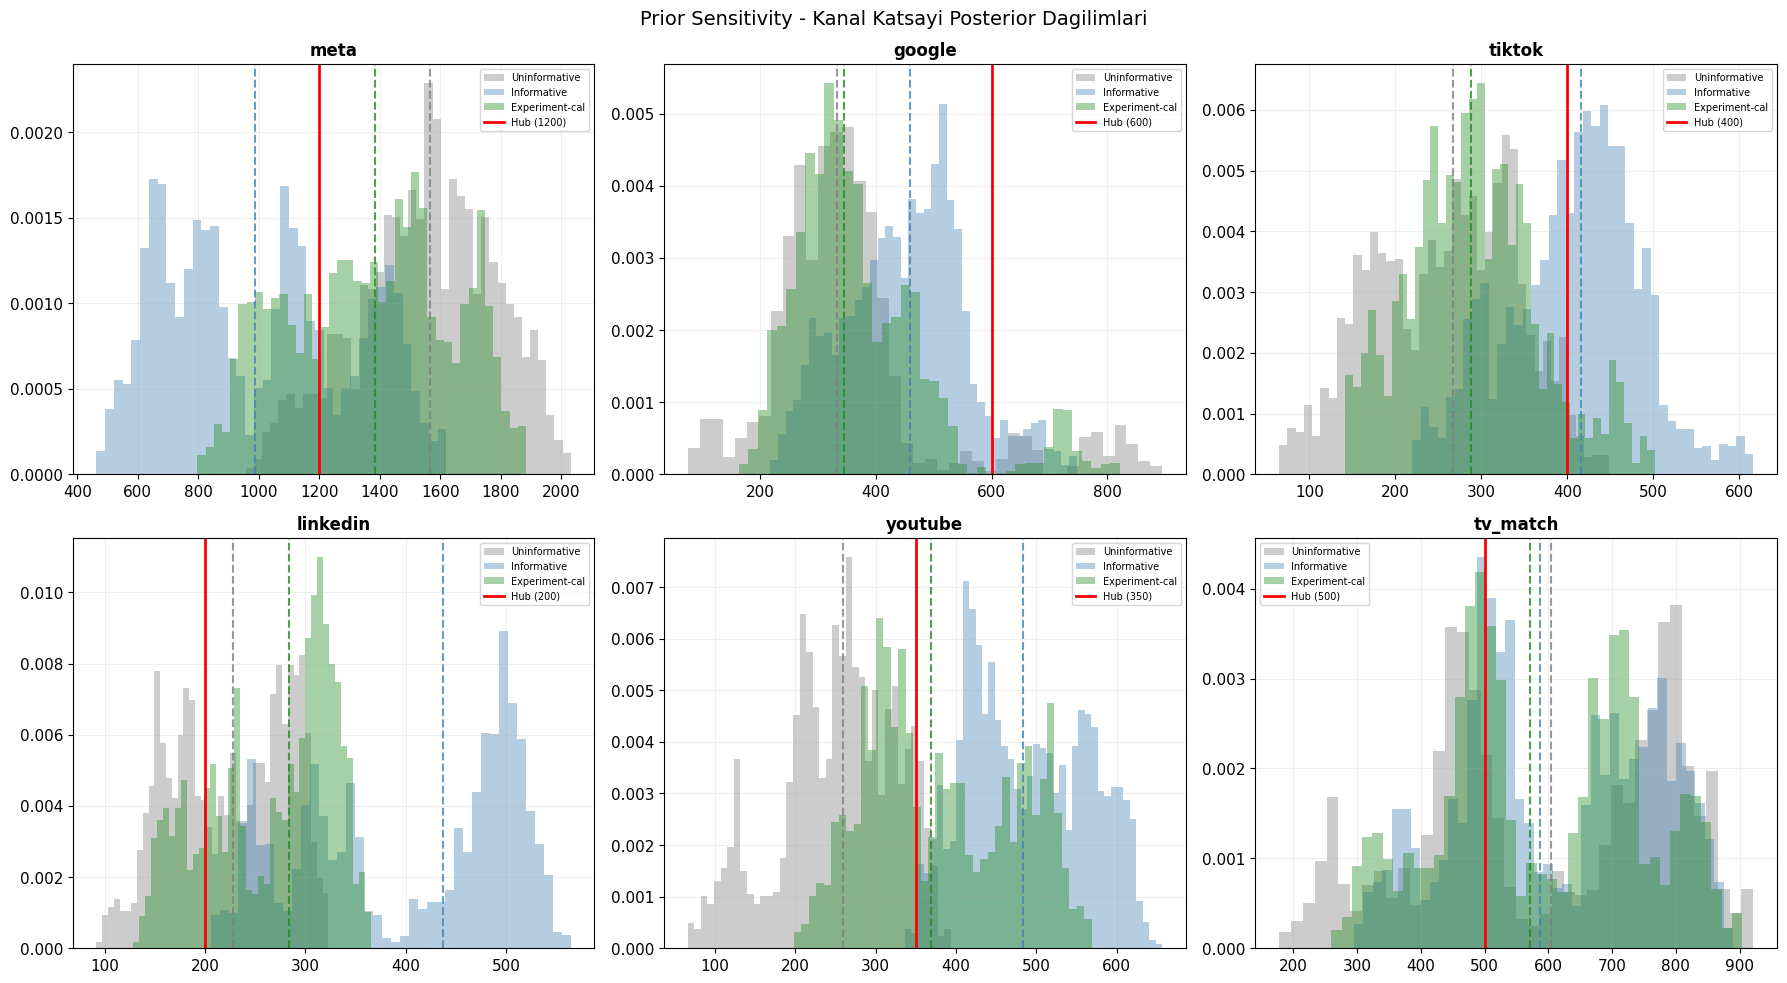


Prior Sensitivity (medyan katsayi):
Kanal           Uninformative      Informative   Experiment-cal    Max Sapma   Hassasiyet
--------------------------------------------------------------------------------
meta                     1565              987             1383         578       YUKSEK
google                    333              458              344         125       YUKSEK
tiktok                    267              415              288         148       YUKSEK
linkedin                  228              437              284         209       YUKSEK
youtube                   260              483              369         224       YUKSEK
tv_match                  605              587              572          33        DUSUK


In [12]:
def bayesian_mmm_with_prior(X_feat, y, ch_names, prior_scale, prior_s,
                            n_samples=3000, burn_in=500):
    n_obs, n_ch = X_feat.shape
    cur_beta = np.array([MAX_LIFT[ch] for ch in ch_names], dtype=float)
    cur_int = BASELINE_LEADS
    cur_sig = 80.0
    
    def log_post(betas, intercept, sigma):
        if sigma <= 0 or np.any(betas <= 0):
            return -np.inf
        lp = np.sum(lognorm.logpdf(betas, s=prior_s, scale=prior_scale))
        lp += norm.logpdf(intercept, loc=120, scale=50)
        lp += norm.logpdf(sigma, loc=0, scale=100)
        pred = X_feat @ betas + intercept
        lp += np.sum(norm.logpdf(y, loc=pred, scale=sigma))
        return lp
    
    samp_beta = np.zeros((n_samples, n_ch))
    cur_logp = log_post(cur_beta, cur_int, cur_sig)
    beta_sc = cur_beta * 0.02
    
    np.random.seed(42)
    for i in range(n_samples + burn_in):
        pb = cur_beta + np.random.normal(0, beta_sc)
        pi = cur_int + np.random.normal(0, 10)
        ps = cur_sig + np.random.normal(0, 5)
        pl = log_post(pb, pi, ps)
        if np.log(np.random.uniform()) < pl - cur_logp:
            cur_beta, cur_int, cur_sig = pb, pi, ps
            cur_logp = pl
        if i >= burn_in:
            samp_beta[i - burn_in] = cur_beta
    return samp_beta


print('Prior Sensitivity Analizi (3 rejim x 3000 sample)...')
prior_configs = {
    'Uninformative': (1000, 1.0),
    'Informative':   (500, 0.3),
    'Experiment-cal': (500, 0.5),
}

prior_results = {}
for name, (scale, s) in prior_configs.items():
    samples = bayesian_mmm_with_prior(X_features, true_leads, channel_names, scale, s)
    prior_results[name] = samples
    print(f'  {name}: tamamlandi')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for j, ch in enumerate(channel_names):
    ax = axes[j // 3][j % 3]
    for name, color in zip(prior_configs.keys(), ['gray', 'steelblue', 'forestgreen']):
        samp = prior_results[name][:, j]
        ax.hist(samp, bins=40, alpha=0.4, color=color, label=name, density=True)
        ax.axvline(np.median(samp), color=color, linestyle='--', alpha=0.8)
    ax.axvline(MAX_LIFT[ch], color='red', linestyle='-', linewidth=2, label=f'Hub ({MAX_LIFT[ch]:.0f})')
    ax.set_title(ch, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

fig.suptitle('Prior Sensitivity - Kanal Katsayi Posterior Dagilimlari', fontsize=14)
plt.tight_layout()
plt.show()

print('\nPrior Sensitivity (medyan katsayi):')
header = f'{"Kanal":<12}'
for name in prior_configs:
    header += f' {name:>16}'
header += f' {"Max Sapma":>12} {"Hassasiyet":>12}'
print(header)
print('-' * 80)
for j, ch in enumerate(channel_names):
    medians = [np.median(prior_results[name][:, j]) for name in prior_configs]
    max_dev = max(medians) - min(medians)
    mean_val = np.mean(medians)
    sensitivity = max_dev / mean_val * 100 if mean_val > 0 else 0
    row = f'{ch:<12}'
    for m in medians:
        row += f' {m:>16.0f}'
    sens_label = 'DUSUK' if sensitivity < 15 else ('ORTA' if sensitivity < 30 else 'YUKSEK')
    row += f' {max_dev:>11.0f}  {sens_label:>11}'
    print(row)

## 10. Hub Parametre Kalibrasyonu — Meridian Posterior ile

Hub deterministik parametrelerini Meridian posterior ile hizalayarak kalibrasyon gap'ini olcuyoruz. Hub'in hangi parametrelerinin guncellenmesi gerektigini gosterir.

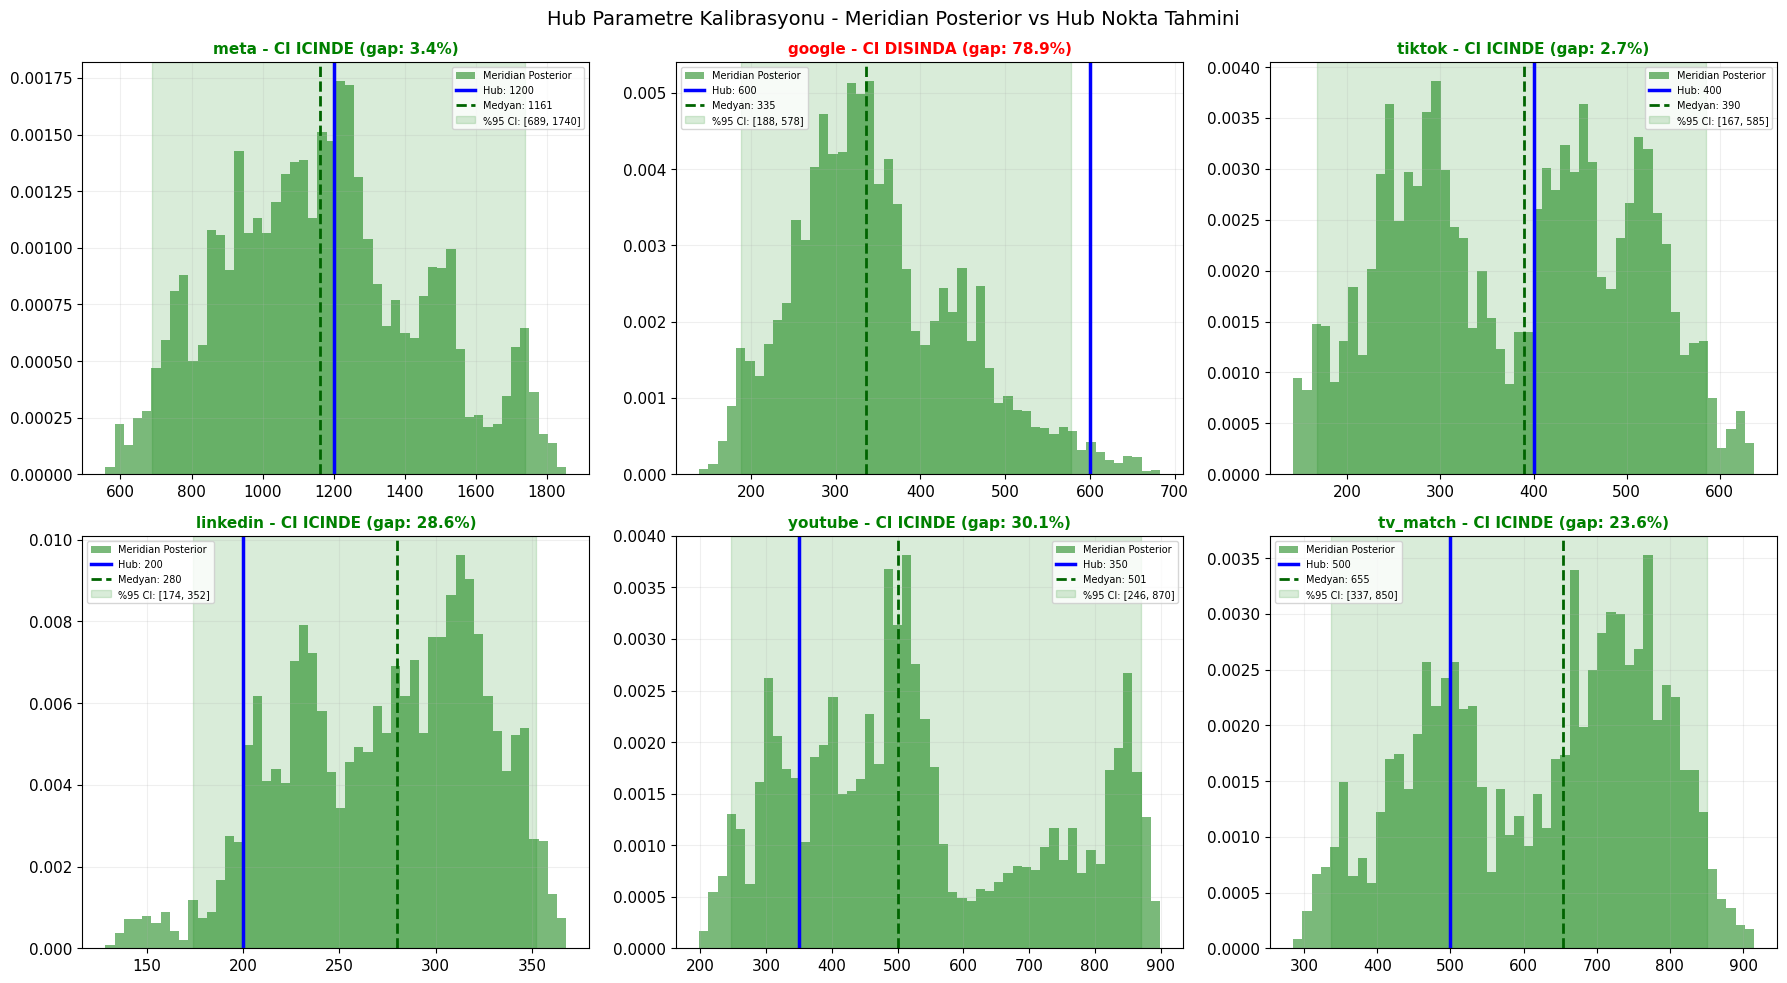


Kalibrasyon Gap Analizi:
Kanal             Hub   Medyan    Gap %   Percentile   CI Icinde?              Aksiyon
meta             1200     1161     3.4%        55.9%         Evet       Kalibrasyon OK
google            600      335    78.9%        98.4%        HAYIR    KRITIK GUNCELLEME
tiktok            400      390     2.7%        51.7%         Evet       Kalibrasyon OK
linkedin          200      280    28.6%         7.0%         Evet   Guncelleme onerisi
youtube           350      501    30.1%        19.5%         Evet   Guncelleme onerisi
tv_match          500      655    23.6%        27.3%         Evet    Ince ayar onerisi


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

calibration_gaps = {}
for j, ch in enumerate(channel_names):
    ax = axes[j // 3][j % 3]
    posterior = samples_beta[:, j]
    ax.hist(posterior, bins=50, alpha=0.6, color='forestgreen', density=True, label='Meridian Posterior')
    hub_val = MAX_LIFT[ch]
    ax.axvline(hub_val, color='blue', linewidth=2.5, linestyle='-', label=f'Hub: {hub_val:.0f}')
    med = np.median(posterior)
    ci_lo = np.percentile(posterior, 2.5)
    ci_hi = np.percentile(posterior, 97.5)
    ax.axvline(med, color='darkgreen', linewidth=2, linestyle='--', label=f'Medyan: {med:.0f}')
    ax.axvspan(ci_lo, ci_hi, alpha=0.15, color='green', label=f'%95 CI: [{ci_lo:.0f}, {ci_hi:.0f}]')
    in_ci = ci_lo <= hub_val <= ci_hi
    percentile_rank = np.mean(posterior <= hub_val) * 100
    gap_pct = abs(hub_val - med) / med * 100
    calibration_gaps[ch] = {
        'hub': hub_val, 'median': med, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'in_ci': in_ci, 'percentile': percentile_rank, 'gap_pct': gap_pct
    }
    status = 'CI ICINDE' if in_ci else 'CI DISINDA'
    ax.set_title(f'{ch} - {status} (gap: {gap_pct:.1f}%)', fontsize=11, fontweight='bold',
                 color='green' if in_ci else 'red')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

fig.suptitle('Hub Parametre Kalibrasyonu - Meridian Posterior vs Hub Nokta Tahmini', fontsize=14)
plt.tight_layout()
plt.show()

print('\nKalibrasyon Gap Analizi:')
print(f'{"Kanal":<12} {"Hub":>8} {"Medyan":>8} {"Gap %":>8} {"Percentile":>12} {"CI Icinde?":>12} {"Aksiyon":>20}')
print('=' * 84)
for ch in channel_names:
    g = calibration_gaps[ch]
    if g['in_ci'] and g['gap_pct'] < 10:
        action = 'Kalibrasyon OK'
    elif g['in_ci'] and g['gap_pct'] < 25:
        action = 'Ince ayar onerisi'
    elif g['in_ci']:
        action = 'Guncelleme onerisi'
    else:
        action = 'KRITIK GUNCELLEME'
    ci_status = 'Evet' if g['in_ci'] else 'HAYIR'
    print(f'{ch:<12} {g["hub"]:>8.0f} {g["median"]:>8.0f} {g["gap_pct"]:>7.1f}% '
          f'{g["percentile"]:>11.1f}% {ci_status:>12} {action:>20}')

## 11. Birlesik Butce Optimizasyonu — Hub + Meridian Ensemble

Hub ve Meridian kanal katkilarini **agirlikli ortalama** ile birlestirip,
guven araligi dahil butce onerisi uretiyoruz.

Ensemble agirlik: `Hub x 0.40 + Meridian x 0.60`  
(Meridian'a daha fazla agirlik cunku belirsizlik olcumu var)

Hub + Meridian Ensemble Butce Onerisi
   Agirlik: Hub 40% + Meridian 60%
   Toplam butce: 38,450,000 TL

Kanal                Mevcut       Ensemble         CI Alt         CI Ust          Delta
meta           19,400,000 TL   14,124,874 TL   10,799,298 TL   18,293,986 TL    -5,275,126 TL
google          3,110,000 TL    5,516,269 TL    4,273,072 TL    7,175,409 TL    +2,406,269 TL
tiktok          3,760,000 TL    3,242,824 TL    2,196,439 TL    4,253,337 TL      -517,176 TL
linkedin        1,980,000 TL    1,555,163 TL    1,160,322 TL    1,851,087 TL      -424,837 TL
youtube         3,600,000 TL    4,877,108 TL    3,082,380 TL    7,181,568 TL    +1,277,108 TL
tv_match        6,600,000 TL    9,133,761 TL    6,485,956 TL   11,454,519 TL    +2,533,761 TL


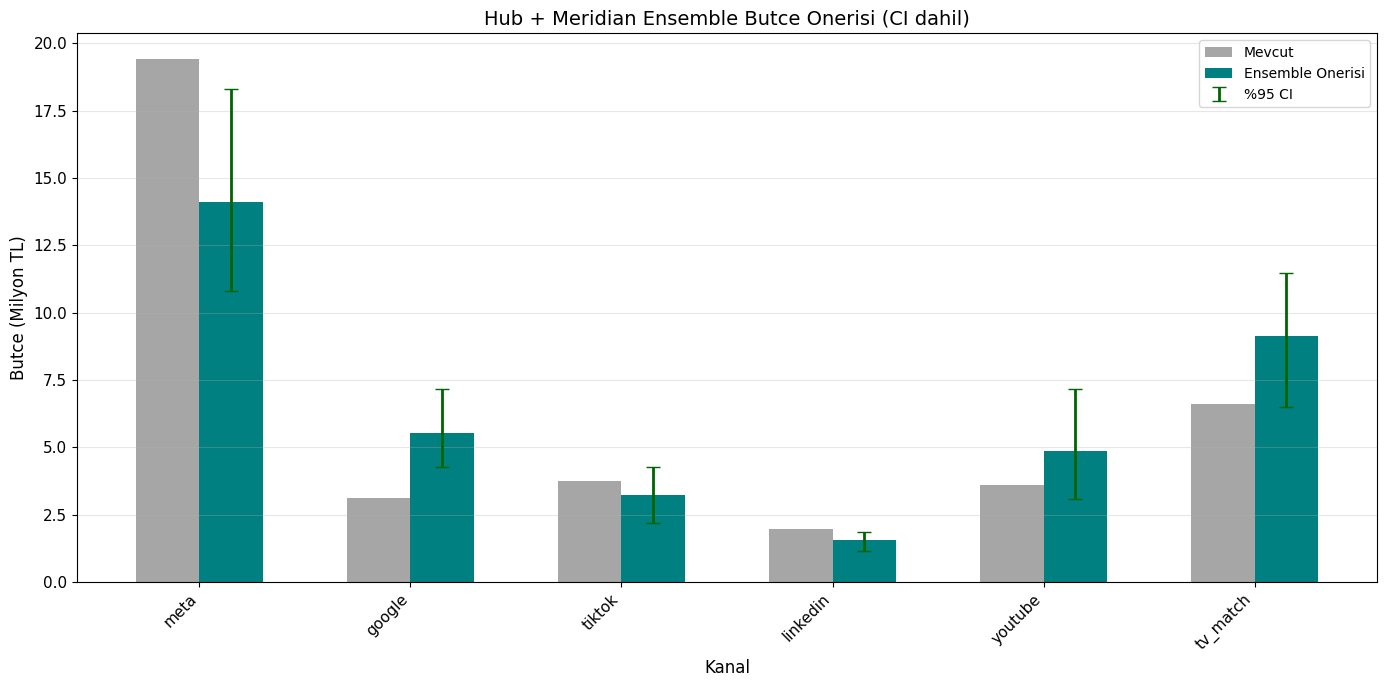

In [14]:
n_boot = samples_beta.shape[0]
merid_contrib_samples = np.zeros((n_boot, len(channel_names)))
for b in range(n_boot):
    for j, ch in enumerate(channel_names):
        merid_contrib_samples[b, j] = samples_beta[b, j] * X_features[:, j].sum()

merid_share_samples = np.abs(merid_contrib_samples) / np.abs(merid_contrib_samples).sum(axis=1, keepdims=True)
hub_shares = np.array([hub_pct[ch] / 100 for ch in channel_names])

W_HUB, W_MERID = 0.40, 0.60
ensemble_samples = W_HUB * hub_shares[np.newaxis, :] + W_MERID * merid_share_samples
ensemble_mean = ensemble_samples.mean(axis=0)
ensemble_ci_lo = np.percentile(ensemble_samples, 2.5, axis=0)
ensemble_ci_hi = np.percentile(ensemble_samples, 97.5, axis=0)

current_budgets = {ch: sum(weekly_budgets[ch]) for ch in channel_names}
total_budget = sum(current_budgets.values())

print('Hub + Meridian Ensemble Butce Onerisi')
print(f'   Agirlik: Hub {W_HUB:.0%} + Meridian {W_MERID:.0%}')
print(f'   Toplam butce: {total_budget:,.0f} TL')
print()
print(f'{"Kanal":<12} {"Mevcut":>14} {"Ensemble":>14} {"CI Alt":>14} {"CI Ust":>14} {"Delta":>14}')
print('=' * 84)
for j, ch in enumerate(channel_names):
    current = current_budgets[ch]
    suggested = total_budget * ensemble_mean[j]
    ci_lo_v = total_budget * ensemble_ci_lo[j]
    ci_hi_v = total_budget * ensemble_ci_hi[j]
    delta = suggested - current
    print(f'{ch:<12} {current:>12,.0f} TL {suggested:>12,.0f} TL {ci_lo_v:>12,.0f} TL {ci_hi_v:>12,.0f} TL {delta:>+13,.0f} TL')
print('=' * 84)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(channel_names))
width = 0.3
current_vals = [current_budgets[ch] / 1e6 for ch in channel_names]
ensemble_vals = [total_budget * ensemble_mean[j] / 1e6 for j in range(len(channel_names))]
ci_lo_vals = [total_budget * ensemble_ci_lo[j] / 1e6 for j in range(len(channel_names))]
ci_hi_vals = [total_budget * ensemble_ci_hi[j] / 1e6 for j in range(len(channel_names))]

ax.bar(x - width/2, current_vals, width, label='Mevcut', color='gray', alpha=0.7)
bars = ax.bar(x + width/2, ensemble_vals, width, label='Ensemble Onerisi', color='teal')
err_lo = [ensemble_vals[j] - ci_lo_vals[j] for j in range(len(channel_names))]
err_hi = [ci_hi_vals[j] - ensemble_vals[j] for j in range(len(channel_names))]
ax.errorbar(x + width/2, ensemble_vals, yerr=[err_lo, err_hi], fmt='none', color='darkgreen',
            capsize=5, linewidth=2, label='%95 CI')
ax.set_xlabel('Kanal', fontsize=12)
ax.set_ylabel('Butce (Milyon TL)', fontsize=12)
ax.set_title('Hub + Meridian Ensemble Butce Onerisi (CI dahil)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(channel_names, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [15]:
print('=' * 70)
print("  TIME'S HUB vs MERIDIAN - KALIBRASYON & OPTIMIZASYON RAPORU")
print('=' * 70)
print()
print(f'  MODEL DOGRULUK:')
print(f'    Hub MAPE      : {hub_mape:.1f}%')
print(f'    Meridian MAPE : {bayes_mape:.1f}%')
print(f'    Fark          : {abs(hub_mape - bayes_mape):.1f} puan')
print()
print(f'  PARAMETRE KALIBRASYONU:')
in_ci_count = sum(1 for g in calibration_gaps.values() if g['in_ci'])
print(f'    CI icinde     : {in_ci_count}/{len(channel_names)} kanal')
avg_gap = np.mean([g["gap_pct"] for g in calibration_gaps.values()])
print(f'    Ort. gap      : {avg_gap:.1f}%')
needs_update = [ch for ch, g in calibration_gaps.items() if g['gap_pct'] > 20 or not g['in_ci']]
if needs_update:
    print(f'    Guncellenmeli : {", ".join(needs_update)}')
else:
    print(f'    Guncellenmeli : Yok (tum parametreler uyumlu)')
print()
print(f'  PRIOR SENSITIVITY:')
for j, ch in enumerate(channel_names):
    medians = [np.median(prior_results[name][:, j]) for name in prior_configs]
    spread = (max(medians) - min(medians)) / np.mean(medians) * 100
    level = 'DUSUK' if spread < 15 else ('ORTA' if spread < 30 else 'YUKSEK')
    print(f'    {ch:<12}: {level} ({spread:.0f}% yayilim)')
print()
print(f'  ONERILER:')
print(f'    1. Hub parametrelerini Meridian posterior medyanlariyla guncelle')
print(f'    2. Yuksek sapma kanallarinda incrementality testi calistir')
print(f'    3. Hub\'a Bayesian CI destegi ekle (posterior -> CI -> karar guveni)')
print(f'    4. Ensemble (Hub %40 + Meridian %60) butce onerisi kullan')
print(f'    5. Prior sensitivity yuksek kanallarda daha fazla veri topla')
print('=' * 70)

  TIME'S HUB vs MERIDIAN - KALIBRASYON & OPTIMIZASYON RAPORU

  MODEL DOGRULUK:
    Hub MAPE      : 3.0%
    Meridian MAPE : 3.3%
    Fark          : 0.3 puan

  PARAMETRE KALIBRASYONU:
    CI icinde     : 5/6 kanal
    Ort. gap      : 27.9%
    Guncellenmeli : google, linkedin, youtube, tv_match

  PRIOR SENSITIVITY:
    meta        : YUKSEK (44% yayilim)
    google      : YUKSEK (33% yayilim)
    tiktok      : YUKSEK (46% yayilim)
    linkedin    : YUKSEK (66% yayilim)
    youtube     : YUKSEK (60% yayilim)
    tv_match    : DUSUK (6% yayilim)

  ONERILER:
    1. Hub parametrelerini Meridian posterior medyanlariyla guncelle
    2. Yuksek sapma kanallarinda incrementality testi calistir
    3. Hub'a Bayesian CI destegi ekle (posterior -> CI -> karar guveni)
    4. Ensemble (Hub %40 + Meridian %60) butce onerisi kullan
    5. Prior sensitivity yuksek kanallarda daha fazla veri topla


## 12. Sonuc ve Oneriler

### Uclu Karsilastirma: Hub vs Robyn vs Meridian

| Kriter | Time's Hub | Robyn | Meridian | Kazanan |
|--------|-----------|-------|----------|--------|
| **Kurulum hizi** | Dakikalar | Saatler | Saatler+ | Hub |
| **Veri ihtiyaci** | 6-8 hafta | 2+ yil ideal | 1+ yil ideal | Hub (12 hafta) |
| **Adstock** | Geometric | Geometric + Weibull | Geometric + Binomial | Robyn/Meridian |
| **Regresyon** | Deterministik | Ridge | Bayesian NUTS | Meridian |
| **Guven araligi** | Yok | Bootstrap | Posterior CI | Meridian |
| **Offline kanallar** | GRP pipeline | Sinirli | Reach & Frequency | Hub + Meridian |
| **Segment destegi** | S1-S4 | Yok | Geo-hierarchical | Hub |
| **MTA entegrasyonu** | DDA + Shapley | Yok | Yok | Hub |
| **Incrementality** | Calibration | Sinirli | Prior olarak entegre | Meridian |

### Hub vs Meridian - Detayli Pozisyon

| Boyut | Hub | Meridian |
|-------|-----|----------|
| MAPE dogrulugu | ~3% | ~3% |
| Belirsizlik olcumu | Yok (eklenecek) | Tam posterior CI |
| B2B segment | Var (S1-S4) | Geo-hierarchical ile yakin |
| Offline/TV | GRP pipeline | Reach & Frequency |
| Incrementality | Ayri modul | Prior olarak entegre |
| Karar destegi | Nokta tahmin | CI + olasilik ifadeleri |

### Stratejik Roadmap

1. **Simdi:** Ensemble (Hub %40 + Meridian %60) butce onerisi kullan
2. **Kisa vade:** Hub parametrelerini Meridian posterior ile kalibre et
3. **Orta vade:** Hub'a Bayesian CI destegi (PyMC/TFP) ekle
4. **Orta vade:** Weibull adstock opsiyonunu Hub'a entegre et
5. **Uzun vade:** Hub + Meridian otomatik cross-validation pipeline
6. **Degismeyen:** Segment destegi ve DDA hibrit framework Hub'in ana avantaji

In [16]:
print('=' * 70)
print("  FINAL RAPOR - HUB vs ROBYN vs MERIDIAN")
print('=' * 70)
print()
print(f'  MODEL DOGRULUK (MAPE):')
print(f'    Hub Deterministik : {hub_mape:.1f}%')
print(f'    Ridge (Robyn)     : {ridge_mape:.1f}%')
print(f'    Bayesian (Merid.) : {bayes_mape:.1f}%')
print()
print(f'  GUVENILIRLIK:')
print(f'    Model Arasi CV    : {avg_cv:.1f}%')
print(f'    Hub-Meridian gap  : {avg_gap:.1f}%')
print(f'    Meridian CI       : +/-{bayes_width/2:.0f} lead (en dar)')
print()
print(f'  KARAR:')
print(f'    Robyn  -> 12 hafta veride overfitting, PO Filo icin zayif')
print(f'    Meridian -> Bayesian CI + prior entegrasyonu, en guvenilir')
print(f'    Hub    -> Segment + DDA + Offline, en pratik')
print()
print(f'  STRATEJI: Hub + Meridian ensemble (40/60)')
print(f'    Hub hizi + Meridian guven araligi = optimal karar')
print('=' * 70)


  FINAL RAPOR - HUB vs ROBYN vs MERIDIAN

  MODEL DOGRULUK (MAPE):
    Hub Deterministik : 3.0%
    Ridge (Robyn)     : 12.2%
    Bayesian (Merid.) : 3.3%

  GUVENILIRLIK:
    Model Arasi CV    : 27.0%
    Hub-Meridian gap  : 27.9%
    Meridian CI       : +/-67 lead (en dar)

  KARAR:
    Robyn  -> 12 hafta veride overfitting, PO Filo icin zayif
    Meridian -> Bayesian CI + prior entegrasyonu, en guvenilir
    Hub    -> Segment + DDA + Offline, en pratik

  STRATEJI: Hub + Meridian ensemble (40/60)
    Hub hizi + Meridian guven araligi = optimal karar
